# Exercise 3: RFID

Pietro Pizzoccheri 10797420 [team leader]  
Lorenzo Bardelli 10831941


## Q1) Compute overall collision resolution efficiency 
$\eta$ for $r_1=1,2,3,4,5,6$

data:
- number of tags $N=4$
- after first frame, frame size is set to current backlog
- given values: $L_2=4$, $L_3=51/8$, and $L_4=953/108$ ($L_4 = 4 + \frac{5}{32}L_4 + \frac{3}{16}\frac{51}{8} + \frac{9}{16}\cdot 4$)
- efficiency: $\eta = N / L_4^*(r_1)$


In [10]:
import itertools
from collections import Counter

N = 4
L = {0: 0.0, 1: 1.0, 2: 4.0, 3: 51/8, 4: 953/108}

def success_distribution(n_tags, r_slots):
    counts = Counter()
    total = r_slots ** n_tags
    for picks in itertools.product(range(r_slots), repeat=n_tags):
        occ = [0] * r_slots
        for p in picks:
            occ[p] += 1
        s = sum(1 for x in occ if x == 1)  # successful tags in first frame
        counts[s] += 1
    return {s: counts[s] / total for s in counts}

rows = []
for r1 in range(1, 7):
    dist = success_distribution(N, r1)
    # L4*(r1) = r1 + sum_{s=0..3} P(S=s) * L[4-s]
    L4_star = r1 + sum(dist.get(s, 0.0) * L[N - s] for s in range(0, N))
    eta = N / L4_star
    rows.append((r1, L4_star, eta))

print(f"{'r1':<4}{'L4*(r1)':<14}{'eta':<12}")
for r1, L4_star, eta in rows:
    print(f"{r1:<4}{L4_star:<14.4f}{eta:<12.4f}")


r1  L4*(r1)       eta         
1   9.8241        0.4072      
2   9.5995        0.4167      
3   8.9544        0.4467      
4   8.8241        0.4533      
5   9.0377        0.4426      
6   9.4661        0.4226      


## Q2) Plot $\eta$ versus $r_1$

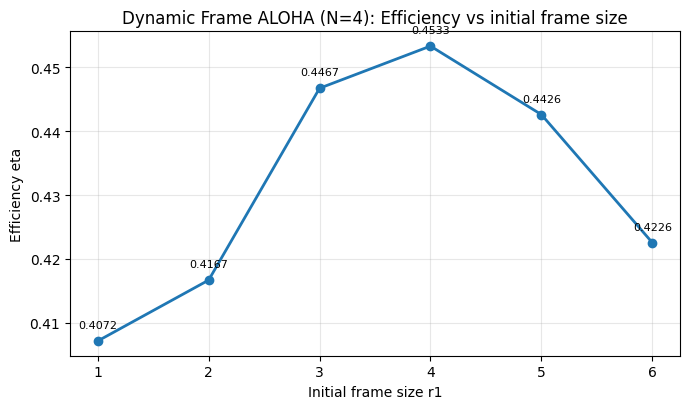

In [11]:
import matplotlib.pyplot as plt

x = [r for r, _, _ in rows]
y = [e for _, _, e in rows]

plt.figure(figsize=(7, 4.2))
plt.plot(x, y, marker='o', linewidth=2)
for xi, yi in zip(x, y):
    plt.text(xi, yi + 0.002, f"{yi:.4f}", ha='center', fontsize=8)
plt.xticks(x)
plt.xlabel('Initial frame size r1')
plt.ylabel('Efficiency eta')
plt.title('Dynamic Frame ALOHA (N=4): Efficiency vs initial frame size')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exercise3_efficiency_plot.png', dpi=160)
plt.show()


## Q3) For which $r_1$ is $\eta$ maximum?


In [12]:
best = max(rows, key=lambda x: x[2])
print(f"Maximum efficiency at r1 = {best[0]}")
print(f"eta_max = {best[2]:.4f}")


Maximum efficiency at r1 = 4
eta_max = 0.4533


this is coherent with the fact that best performance in ALOHA is when frame size is close to backlog size (r ~ n)

if r1 is too small, collisions increase, if r1 is too large, empty slots increase